In [194]:
import cv2
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
from scipy.ndimage import laplace

In [187]:
src_img = np.array(Image.open("../frames/glasses.png").convert("RGB").resize((512, 512)))
bg_img = np.array(Image.open("../frames/facetest2.png").convert("RGB").resize((512, 512)))
mask_img = np.array(Image.open("../frames/glasses_mask.png").convert("L").resize((512, 512))) / 255.0
combined_img = np.array(Image.open("../frames/simple_composite.png").convert("RGB").resize((512, 512)))

conducted 0 iterations
conducted 100 iterations
conducted 200 iterations
conducted 300 iterations
conducted 400 iterations
conducted 500 iterations
conducted 600 iterations
conducted 700 iterations
conducted 800 iterations
conducted 900 iterations
conducted 1000 iterations
conducted 1100 iterations
conducted 1200 iterations
conducted 1300 iterations
conducted 1400 iterations
conducted 1500 iterations
conducted 1600 iterations
conducted 1700 iterations
conducted 1800 iterations
conducted 1900 iterations
conducted 2000 iterations
conducted 0 iterations
conducted 100 iterations
conducted 200 iterations
conducted 300 iterations
conducted 400 iterations
conducted 500 iterations
conducted 600 iterations
conducted 700 iterations
conducted 800 iterations
conducted 900 iterations
conducted 1000 iterations
conducted 1100 iterations
conducted 1200 iterations
conducted 1300 iterations
conducted 1400 iterations
conducted 1500 iterations
conducted 1600 iterations
conducted 1700 iterations
conducted 

(-0.5, 511.5, 511.5, -0.5)

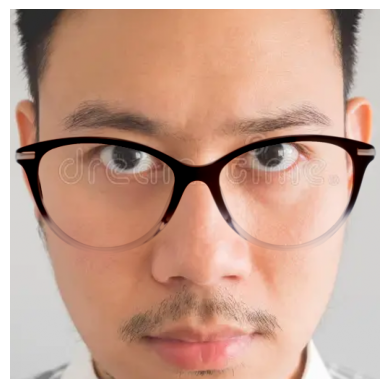

In [195]:
# POISSON BLEND

def poisson_blend(src_img, bg_img, mask_img):
    src_img = src_img / 255.0
    bg_img = bg_img / 255.0

    src_coords = np.argwhere(mask_img)

    src_top, src_left = np.min(src_coords, axis=0) - 1
    src_bottom, src_right = np.max(src_coords, axis=0) + 1

    mask_patch = mask_img[src_top : src_bottom + 1, src_left : src_right + 1]
    src_patch = src_img[src_top : src_bottom + 1, src_left : src_right + 1]

    target_top, target_left = (src_top + bg_img.shape[0] - src_img.shape[0], src_left + bg_img.shape[1] - src_img.shape[1])

    target_bottom, target_right = (
        target_top + mask_patch.shape[0],
        target_left + mask_patch.shape[1],
    )

    target_patch = bg_img[target_top:target_bottom, target_left:target_right]

    blend_patch = np.stack(
        [
            poisson_blend_helper(target_patch[:, :, i], src_patch[:, :, i], mask_patch)
            for i in range(3) # i = 0 for red, i = 1 for green, i = 2 for blue
        ],
        axis=2,
    )
    
    blended_full = bg_img.copy()
    blended_full[target_top:target_bottom, target_left:target_right] = blend_patch
    
    return blended_full

def poisson_blend_helper(target_img, src_img, mask_img, iter: int = 2048):
    assert target_img.shape == src_img.shape, "Images must match"
    for i in range(iter):
        if i % 100 == 0:
          print(f"conducted {i} iterations")
        target_img = target_img + 0.25 * mask_img * laplace(target_img - src_img)
    return target_img.clip(0, 1)

poisson = poisson_blend(src_img, bg_img, mask_img)
plt.imshow(poisson)
plt.axis('off')

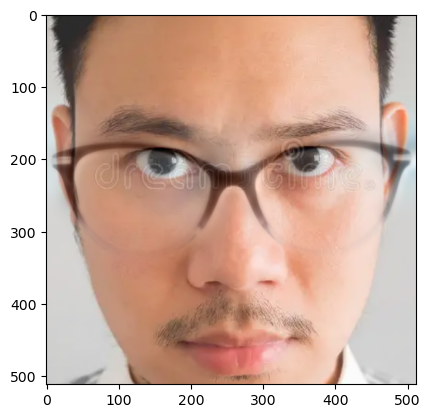

In [ ]:
# MULTISCALE HARMONIZATION

# Main idea is to

# 1. Generate Gaussian Pyramid for mask
#         (allows blending on diverse levels of detail)

# 2. Generate Laplassian Pyramids for images
#         (captures the difference between adjacent levels of the Gaussian pyramid)
#         (separates the fine details <high frequencies> from the coarse ones <low frequencies>)

# 3. Blend Pyramids
#         (At each level of the pyramids, the images are blended based on the mask's corresponding level.
#           The mask defines how much of the source and destination images should be mixed at each level.
#           This way of blending helps to ensure the smooth and natural transition between the images
#          )

# 4. Reconstruct final image from blended pyramid
#         (By starting from the smallest level of the pyramid and successively upscaling
#           and adding the details from each level
#         )

def multiscale_harmonization(src, mask, dst, levels=6):
    """Multi-scale pyramid harmonization"""
    
    # Build pyramids
    src_pyramid = build_laplacian_pyramid(src, levels)
    dst_pyramid = build_laplacian_pyramid(dst, levels)
    
    # Create mask pyramid
    mask_pyramid = [mask]
    for i in range(levels):
        mask_pyramid.append(cv2.pyrDown(mask_pyramid[i]))
    
    # Blend pyramids
    blended_pyramid = []
    for i in range(len(src_pyramid)):
        # Resize mask to match current level
        if i < len(mask_pyramid):
            current_mask = mask_pyramid[i]
        else:
            current_mask = mask_pyramid[-1]
        
        # Ensure mask has same dimensions as pyramid level
        if current_mask.shape[:2] != src_pyramid[i].shape[:2]:
            current_mask = cv2.resize(current_mask, 
                                    (src_pyramid[i].shape[1], src_pyramid[i].shape[0]))
        
        # Extend mask to 3 channels if needed
        if len(current_mask.shape) == 2:
            current_mask = np.stack([current_mask] * 3, axis=2)
        
        # Blend current level
        blended = src_pyramid[i] * current_mask + dst_pyramid[i] * (1 - current_mask)
        blended_pyramid.append(blended)
    
    # Reconstruct
    result = reconstruct_from_laplacian_pyramid(blended_pyramid)
    
    return result

def build_laplacian_pyramid(image, levels=4):
    """Build Laplacian pyramid"""
    gaussian_pyramid = [image.astype(np.float32)]
    
    for i in range(levels):
        gaussian_pyramid.append(cv2.pyrDown(gaussian_pyramid[i]))
    
    laplacian_pyramid = [gaussian_pyramid[levels]]
    
    for i in range(levels, 0, -1):
        size = (gaussian_pyramid[i-1].shape[1], gaussian_pyramid[i-1].shape[0])
        gaussian_expanded = cv2.pyrUp(gaussian_pyramid[i], dstsize=size)
        laplacian = cv2.subtract(gaussian_pyramid[i-1], gaussian_expanded)
        laplacian_pyramid.append(laplacian)
    
    return laplacian_pyramid

def reconstruct_from_laplacian_pyramid(laplacian_pyramid):
    """Reconstruct image from Laplacian pyramid"""
    reconstructed = laplacian_pyramid[0]
    
    for i in range(1, len(laplacian_pyramid)):
        size = (laplacian_pyramid[i].shape[1], laplacian_pyramid[i].shape[0])
        reconstructed = cv2.pyrUp(reconstructed, dstsize=size)
        reconstructed = cv2.add(reconstructed, laplacian_pyramid[i])
    
    return np.clip(reconstructed, 0, 255).astype(np.uint8)

multiscale = multiscale_harmonization(src_img, mask_img, bg_img)
plt.imshow(multiscale)


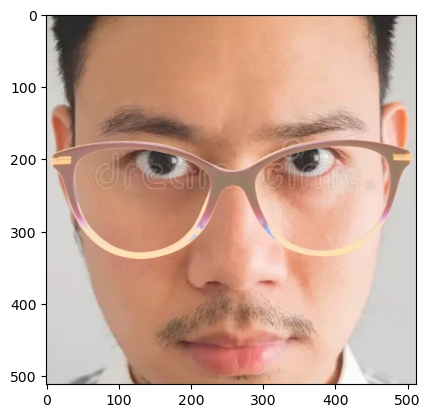

In [193]:
# COLOUR TRANSFER

def color_transfer_harmonization(src, mask, dst):
    """Color transfer harmonization using LAB color space"""
    # Convert to LAB color space
    src_lab = cv2.cvtColor(src, cv2.COLOR_RGB2LAB).astype(np.float32)
    dst_lab = cv2.cvtColor(dst, cv2.COLOR_RGB2LAB).astype(np.float32)
    
    # Get background region statistics
    bg_mask = (1 - mask) > 0.5
    bg_mask_3d = np.stack([bg_mask] * 3, axis=2)
    
    # Calculate mean and std for background
    bg_mean = np.mean(dst_lab[bg_mask_3d].reshape(-1, 3), axis=0)
    bg_std = np.std(dst_lab[bg_mask_3d].reshape(-1, 3), axis=0)
    
    # Get foreground region statistics
    fg_mask = mask > 0.5
    fg_mask_3d = np.stack([fg_mask] * 3, axis=2)
    
    # Calculate mean and std for foreground
    fg_mean = np.mean(src_lab[fg_mask_3d].reshape(-1, 3), axis=0)
    fg_std = np.std(src_lab[fg_mask_3d].reshape(-1, 3), axis=0)
    
    # Prevent division by zero
    fg_std = np.where(fg_std == 0, 1e-6, fg_std)
    
    # Color transfer
    src_lab_corrected = src_lab.copy()
    
    # Apply color transfer to foreground region
    for i in range(3):
        src_lab_corrected[:, :, i] = (src_lab[:, :, i] - fg_mean[i]) * (bg_std[i] / fg_std[i]) + bg_mean[i]
    
    # Convert back to RGB
    result_rgb = cv2.cvtColor(src_lab_corrected.astype(np.uint8), cv2.COLOR_LAB2RGB)
    
    # Blend with original background
    mask_3d = np.stack([mask] * 3, axis=2)
    result = dst.copy().astype(np.uint8)
    result = result * (1 - mask_3d) + result_rgb * mask_3d
    
    return result.astype(np.uint8)

color_transfer = color_transfer_harmonization(src_img, mask_img, bg_img)
plt.imshow(color_transfer)

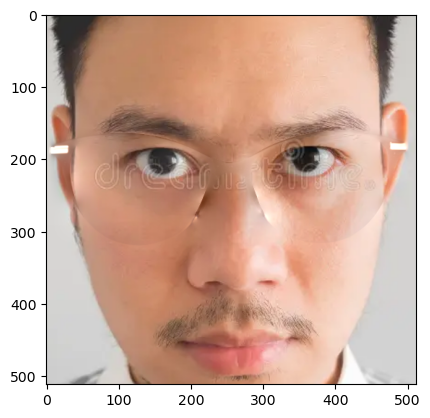

In [196]:
# POISSON SEAMLESS CLONE

def poisson_blending(src, mask, dst):
    """Traditional Poisson blending using OpenCV's seamlessClone"""
    mask_binary = (mask > 0.5).astype(np.uint8) * 255

    moments = cv2.moments(mask_binary)
    if moments["m00"] != 0:
        cx = int(moments["m10"] / moments["m00"])
        cy = int(moments["m01"] / moments["m00"])
    else:
        cy, cx = np.unravel_index(np.argmax(mask_binary), mask_binary.shape)
    
    center = (cx, cy)
    result = cv2.seamlessClone(src, dst, mask_binary, center, cv2.NORMAL_CLONE)
    return result

poisson = poisson_blending(src_img, mask_img, bg_img)
plt.imshow(poisson)

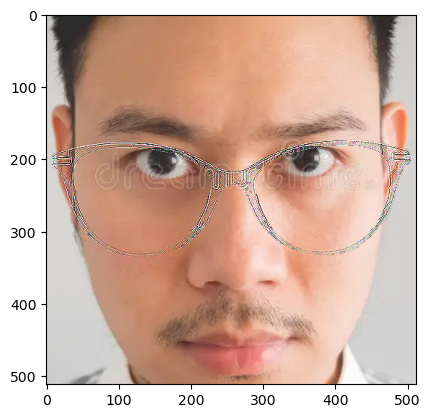

In [159]:
# GRADIENT DOMAIN HARMONIZATION

def gradient_domain_harmonization(src, mask, dst):
    """Gradient domain harmonization using optimization"""
    h, w = src.shape[:2]
    
    # Create binary mask
    binary_mask = (mask > 0.5).astype(np.uint8)
    
    # Create boundary mask
    kernel = np.ones((3, 3), np.uint8)
    boundary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_GRADIENT, kernel)
    
    result = dst.copy()
    
    # Process each color channel
    for channel in range(3):
        src_channel = src[:, :, channel].astype(np.float32)
        dst_channel = dst[:, :, channel].astype(np.float32)
        
        # Compute gradients
        grad_x = cv2.Sobel(src_channel, cv2.CV_32F, 1, 0, ksize=3)
        grad_y = cv2.Sobel(src_channel, cv2.CV_32F, 0, 1, ksize=3)
        
        # Apply gradient modification in the boundary region
        boundary_region = boundary_mask > 0
        
        # Smooth gradients at boundary
        if np.any(boundary_region):
            grad_x[boundary_region] *= 0.5
            grad_y[boundary_region] *= 0.5
        
        # Simple gradient integration (approximate)
        # Use iterative approach to integrate gradients
        integrated = dst_channel.copy()
        fg_region = binary_mask > 0
        
        # Iteratively adjust foreground region
        for _ in range(11):
            # Compute divergence
            div = cv2.Laplacian(integrated, cv2.CV_32F)
            target_div = cv2.Laplacian(src_channel, cv2.CV_32F)
            
            # Update only foreground region
            integrated[fg_region] += 0.1 * (target_div[fg_region] - div[fg_region])
            
            # Ensure boundary conditions
            integrated[boundary_region] = 0.5 * (integrated[boundary_region] + dst_channel[boundary_region])
        
        result[:, :, channel] = np.clip(integrated, 0, 255)
    
    return result.astype(np.uint8)

gradient_domain = gradient_domain_harmonization(src_img, mask_img, bg_img)
plt.imshow(gradient_domain)

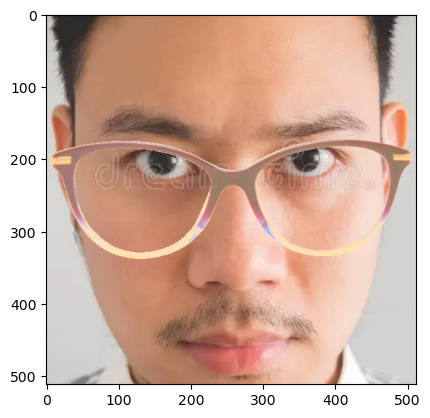

In [156]:
# STYLE TRANSFER

def style_transfer_harmonization(src, mask, dst):
    """Style transfer-based harmonization using neural style transfer concepts"""
    
    # Convert to LAB color space for better color manipulation
    src_lab = cv2.cvtColor(src, cv2.COLOR_RGB2LAB).astype(np.float32)
    dst_lab = cv2.cvtColor(dst, cv2.COLOR_RGB2LAB).astype(np.float32)
    
    # Extract style (color statistics) from background
    bg_mask = (1 - mask) > 0.5
    bg_pixels = dst_lab[bg_mask]
    
    # Calculate style statistics
    bg_mean = np.mean(bg_pixels, axis=0)
    bg_std = np.std(bg_pixels, axis=0)
    
    # Apply style transfer to foreground
    fg_mask = mask > 0.5
    fg_pixels = src_lab[fg_mask]
    
    if len(fg_pixels) > 0:
        fg_mean = np.mean(fg_pixels, axis=0)
        fg_std = np.std(fg_pixels, axis=0)
        
        # Prevent division by zero
        fg_std = np.where(fg_std == 0, 1e-6, fg_std)
        
        # Style transfer: match mean and std
        stylized_fg = (fg_pixels - fg_mean) / fg_std * bg_std + bg_mean
        
        # Apply stylized colors back to image
        result_lab = dst_lab.copy()
        result_lab[fg_mask] = stylized_fg
        
        # Convert back to RGB
        result = cv2.cvtColor(result_lab.astype(np.uint8), cv2.COLOR_LAB2RGB)
        
        # Additional texture matching using gradient information
        src_gray = cv2.cvtColor(src, cv2.COLOR_RGB2GRAY)
        dst_gray = cv2.cvtColor(dst, cv2.COLOR_RGB2GRAY)
        
        # Compute gradients
        src_grad = cv2.Laplacian(src_gray, cv2.CV_32F)
        dst_grad = cv2.Laplacian(dst_gray, cv2.CV_32F)
        
        # Match gradient statistics
        fg_grad = src_grad[fg_mask]
        bg_grad = dst_grad[bg_mask]
        
        if len(bg_grad) > 0:
            grad_scale = np.std(bg_grad) / (np.std(fg_grad) + 1e-6)
            
            # Apply gradient matching
            for c in range(3):
                channel = result[:, :, c].astype(np.float32)
                channel[fg_mask] = channel[fg_mask] + grad_scale * src_grad[fg_mask] * 0.1
                result[:, :, c] = np.clip(channel, 0, 255)
        
        return result.astype(np.uint8)
    
    return dst

style_transfer = style_transfer_harmonization(src_img, mask_img, bg_img)
plt.imshow(style_transfer)

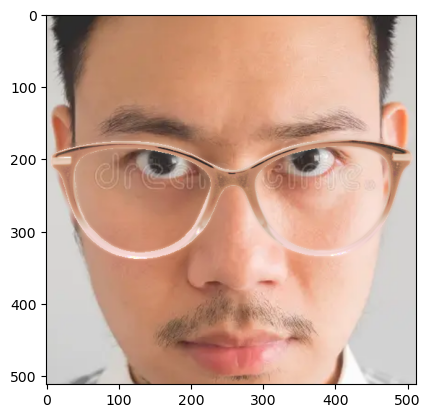

In [ ]:
# HISTOGRAM MATCHING

def histogram_matching_with_coherence(src, mask, dst):
    """Histogram matching with spatial coherence constraints"""
    
    result = dst.copy()
    
    # Process each color channel separately
    for channel in range(3):
        src_channel = src[:, :, channel]
        dst_channel = dst[:, :, channel]
        
        # Get foreground and background histograms
        fg_mask = mask > 0.5
        bg_mask = (1 - mask) > 0.5
        
        fg_pixels = src_channel[fg_mask]
        bg_pixels = dst_channel[bg_mask]
        
        if len(fg_pixels) > 0 and len(bg_pixels) > 0:
            # Compute histograms
            fg_hist, fg_bins = np.histogram(fg_pixels, bins=256, range=(0, 255))
            bg_hist, bg_bins = np.histogram(bg_pixels, bins=256, range=(0, 255))
            
            # Compute cumulative distributions
            fg_cdf = fg_hist.cumsum()
            bg_cdf = bg_hist.cumsum()
            
            # Normalize
            fg_cdf = fg_cdf / fg_cdf[-1]
            bg_cdf = bg_cdf / bg_cdf[-1]
            
            # Create lookup table for histogram matching
            lut = np.zeros(256, dtype=np.uint8)
            for i in range(256):
                # Find closest value in background CDF
                diff = np.abs(bg_cdf - fg_cdf[i])
                lut[i] = np.argmin(diff)
            
            # Apply histogram matching
            matched_channel = result[:, :, channel].copy()
            matched_channel[fg_mask] = lut[src_channel[fg_mask]]
            
            # Apply spatial coherence using edge-preserving smoothing
            # Create a weight map based on distance from mask boundary
            kernel = np.ones((3, 3), np.uint8)
            dilated_mask = cv2.dilate(mask, kernel, iterations=5)
            
            # Smooth the transition region
            transition_mask = dilated_mask - mask
            transition_mask = transition_mask > 0.5
            
            if np.any(transition_mask):
                # Apply bilateral filter to preserve edges while smoothing
                smoothed = cv2.bilateralFilter(matched_channel, 9, 75, 75)
                matched_channel[transition_mask] = smoothed[transition_mask]
            
            result[:, :, channel] = matched_channel
            
    return result

hist_match = histogram_matching_with_coherence(src_img, mask_img, bg_img)
plt.imshow(hist_match)    

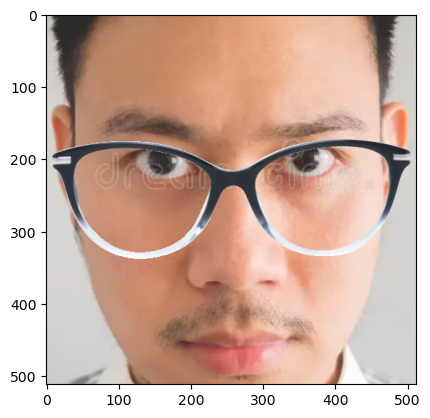

In [145]:
# MORPHOLOGICAL GRADIENT

def morphological_gradient_harmonization(src, mask, dst):
    """Morphological gradient-based harmonization"""
    
    # Convert to grayscale for morphological operations
    src_gray = cv2.cvtColor(src, cv2.COLOR_RGB2GRAY)
    dst_gray = cv2.cvtColor(dst, cv2.COLOR_RGB2GRAY)
    
    # Create morphological kernels
    kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    
    # Compute morphological gradients
    src_grad = cv2.morphologyEx(src_gray, cv2.MORPH_GRADIENT, kernel_small)
    dst_grad = cv2.morphologyEx(dst_gray, cv2.MORPH_GRADIENT, kernel_small)
    
    # Compute texture features using morphological operations
    src_tophat = cv2.morphologyEx(src_gray, cv2.MORPH_TOPHAT, kernel_large)
    dst_tophat = cv2.morphologyEx(dst_gray, cv2.MORPH_TOPHAT, kernel_large)
    
    # Get foreground and background regions
    fg_mask = mask > 0.5
    bg_mask = (1 - mask) > 0.5
    
    # Compute statistics for gradient matching
    if np.any(fg_mask) and np.any(bg_mask):
        
        # gradient stats
        fg_grad_mean = np.mean(src_grad[fg_mask])
        fg_grad_std = np.std(src_grad[fg_mask])
        bg_grad_mean = np.mean(dst_grad[bg_mask])
        bg_grad_std = np.std(dst_grad[bg_mask])
        
        # tophat stats
        fg_tophat_mean = np.mean(src_tophat[fg_mask])
        fg_tophat_std = np.std(src_tophat[fg_mask])
        bg_tophat_mean = np.mean(dst_tophat[bg_mask])
        bg_tophat_std = np.std(dst_tophat[bg_mask])
        
        # Match gradient statistics
        if fg_grad_std > 0:
            grad_scale = bg_grad_std / fg_grad_std
            grad_shift = bg_grad_mean - fg_grad_mean * grad_scale
        else:
            grad_scale = 1.0
            grad_shift = 0.0
        
        # Top-hat scale and shift
        if fg_tophat_std > 0:
            tophat_scale = bg_tophat_std / fg_tophat_std
            tophat_shift = bg_tophat_mean - fg_tophat_mean * tophat_scale
        else:
            tophat_scale = 1.0
            tophat_shift = 0.0
        
        # Apply gradient matching to each color channel
        result = dst.copy()
        
        for channel in range(3):
            src_channel = src[:, :, channel].astype(np.float32)
            dst_channel = dst[:, :, channel].astype(np.float32)
            
            # Apply gradient-based adjustment
            adjusted_channel = dst_channel.copy()
            
            # Use morphological gradient to guide the adjustment
            grad_adj = (src_grad.astype(np.float32) * grad_scale + grad_shift - src_grad.astype(np.float32)) * 0.1
            # Top-hat adjustment
            tophat_adj = (src_tophat.astype(np.float32) * tophat_scale + tophat_shift - src_tophat.astype(np.float32)) * 0.1
            
            # Combine adjustments
            combined_adj = grad_adj + tophat_adj
            
            # Apply adjustment only to foreground region
            adjusted_channel[fg_mask] = src_channel[fg_mask] + combined_adj[fg_mask]
            
            # Ensure values are in valid range
            adjusted_channel = np.clip(adjusted_channel, 0, 255)
            
            result[:, :, channel] = adjusted_channel
        
        # Apply morphological closing to smooth the result
        for channel in range(3):
            result[:, :, channel] = cv2.morphologyEx(
                result[:, :, channel].astype(np.uint8), 
                cv2.MORPH_CLOSE, 
                kernel_small
            )
    
    else:
        result = dst.copy()
    
    return result.astype(np.uint8)

morphological_gradient = morphological_gradient_harmonization(src_img, mask_img, bg_img)
plt.imshow(morphological_gradient)

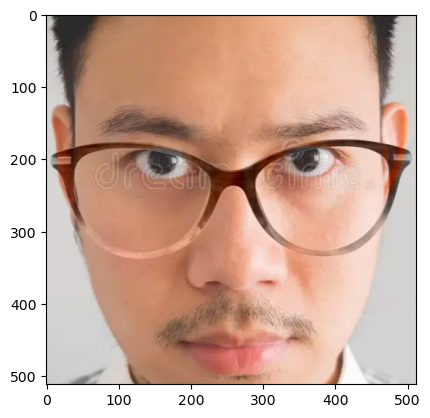

In [151]:
# FREQUENCY DOMAIN

def frequency_domain_harmonization(src, mask, dst):
    """Frequency domain harmonization using FFT on luminance only"""
    
    # Convert to YUV color space
    src_yuv = cv2.cvtColor(src, cv2.COLOR_RGB2YUV).astype(np.float32)
    dst_yuv = cv2.cvtColor(dst, cv2.COLOR_RGB2YUV).astype(np.float32)
    
    result_yuv = dst_yuv.copy()
    
    # Harmonize only the Y (luminance) channel
    channel = 0  # Y
    src_channel = src_yuv[:, :, channel]
    dst_channel = dst_yuv[:, :, channel]
    
    # Apply FFT
    src_fft = np.fft.fft2(src_channel)
    dst_fft = np.fft.fft2(dst_channel)
    
    # Shift zero freq to center
    src_fft_shifted = np.fft.fftshift(src_fft)
    dst_fft_shifted = np.fft.fftshift(dst_fft)
    
    # Magnitude and phase
    src_magnitude = np.abs(src_fft_shifted)
    src_phase = np.angle(src_fft_shifted)
    
    dst_magnitude = np.abs(dst_fft_shifted)
    dst_phase = np.angle(dst_fft_shifted)
    
    # Create low-pass filter mask
    h, w = src_channel.shape
    center_h, center_w = h // 2, w // 2
    y, x = np.ogrid[:h, :w]
    freq_mask = ((x - center_w) ** 2 + (y - center_h) ** 2) <= (min(h, w) * 0.1) ** 2
    
    if np.any(mask > 0.5):
        # Match magnitude
        fg_mag_mean = np.mean(src_magnitude[freq_mask])
        bg_mag_mean = np.mean(dst_magnitude[freq_mask])
        
        mag_scale = bg_mag_mean / fg_mag_mean if fg_mag_mean > 0 else 1.0
        
        harmonized_magnitude = src_magnitude * mag_scale
        harmonized_phase = src_phase
        
        # Blend with destination
        blended_magnitude = harmonized_magnitude * 0.7 + dst_magnitude * 0.3
        blended_phase = harmonized_phase * 0.8 + dst_phase * 0.2
        
        harmonized_fft = blended_magnitude * np.exp(1j * blended_phase)
        harmonized_fft = np.fft.ifftshift(harmonized_fft)
        harmonized_channel = np.real(np.fft.ifft2(harmonized_fft))
        
        # Clip and blend
        harmonized_channel = np.clip(harmonized_channel, 0, 255)
        result_yuv[:, :, channel] = dst_channel * (1 - mask) + harmonized_channel * mask
    
    # Clip and convert back
    result_yuv = np.clip(result_yuv, 0, 255).astype(np.uint8)
    result = cv2.cvtColor(result_yuv, cv2.COLOR_YUV2RGB)
    
    return result


frequency_domain_result = frequency_domain_harmonization(src_img, mask_img, bg_img)
plt.imshow(frequency_domain_result)